# 1. Data Selection

In [1]:
from google.colab import files
uploaded = files.upload()

Saving my_file (1).csv to my_file (1).csv


In [2]:
import pandas as pd

In [3]:
tours_data = pd.read_csv(list(uploaded.keys())[0])

#2. Data Inpection & Profiling

In [4]:
# Check data types and non-null counts
tours_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Rank                              20 non-null     int64 
 1   Peak                              9 non-null      object
 2   All Time Peak                     6 non-null      object
 3   Actual gross                      20 non-null     object
 4   Adjusted gross (in 2022 dollars)  20 non-null     object
 5   Artist                            20 non-null     object
 6   Tour title                        20 non-null     object
 7   Year(s)                           20 non-null     object
 8   Shows                             20 non-null     int64 
 9   Average gross                     20 non-null     object
 10  Ref.                              20 non-null     object
dtypes: int64(2), object(9)
memory usage: 1.8+ KB


In [5]:
# Count missing values per column
tours_data.isnull().sum()

,0
Rank,0
Peak,11
All Time Peak,14
Actual gross,0
Adjusted gross (in 2022 dollars),0
Artist,0
Tour title,0
Year(s),0
Shows,0
Average gross,0


In [6]:
# Number of unique values per column
tours_data.nunique()

# Preview the actual unique values for a specific column
tours_data['Artist'].unique()


array(['Taylor Swift', 'Beyoncé', 'Madonna', 'Pink', 'Celine Dion',
       'Lady Gaga', 'Katy Perry', 'Cher', 'Adele'], dtype=object)

In [9]:
# Value counts for column
tours_data['Artist'].value_counts()



,count
Artist,
Taylor Swift,4
Madonna,4
Beyoncé,3
Pink,3
Lady Gaga,2
Celine Dion,1
Katy Perry,1
Cher,1
Adele,1


In [11]:
tours_data['Shows'].value_counts()

,count
Shows,
56,2
85,2
156,1
53,1
88,1
131,1
41,1
49,1
132,1


In [12]:
# Count duplicates
tours_data.duplicated().sum()

# Show actual duplicate rows if any
tours_data[tours_data.duplicated()]


,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.


#3. Data Cleaning

In [13]:
# Check missing values again
print("Missing values per column:")
print(tours_data.isnull().sum())



Missing values per column:
Rank                                 0
Peak                                11
All Time Peak                       14
Actual gross                         0
Adjusted gross (in 2022 dollars)     0
Artist                               0
Tour title                           0
Year(s)                              0
Shows                                0
Average gross                        0
Ref.                                 0
dtype: int64


In [14]:
# Drop the 'All Time Peak' column
if 'All Time Peak' in tours_data.columns:
    tours_data.drop(columns=['All Time Peak'], inplace=True)

In [17]:
# Drop the 'Peak' column
if 'Peak' in tours_data.columns:
    tours_data.drop(columns=['Peak'], inplace=True)

In [18]:
# Check result
print(tours_data.isnull().sum())
tours_data.head()

Rank                                0
Actual gross                        0
Adjusted gross (in 2022 dollars)    0
Artist                              0
Tour title                          0
Year(s)                             0
Shows                               0
Average gross                       0
Ref.                                0
dtype: int64


,Rank,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


In [30]:
# Rename 'Actual gross' to "Actual Gross (USD)"

tours_data = tours_data.rename(columns={'Actual gross': 'Actual Gross (USD)'})

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary statistics
print(tours_data.describe(include='all'))

             Rank  Actual gross Adjusted gross (in 2022 dollars)  \
count   20.000000            20                               20   
unique        NaN            20                               20   
top           NaN  $780,000,000                     $780,000,000   
freq          NaN             1                                1   
mean    10.450000           NaN                              NaN   
std      5.942488           NaN                              NaN   
min      1.000000           NaN                              NaN   
25%      5.750000           NaN                              NaN   
50%     10.500000           NaN                              NaN   
75%     15.250000           NaN                              NaN   
max     20.000000           NaN                              NaN   

              Artist       Tour title    Year(s)       Shows Average gross  \
count             20               20         20   20.000000            20   
unique             9       

We needed to know

In [33]:
print(tours_data.columns.tolist())

['Rank', 'Actual\xa0gross', 'Adjusted\xa0gross (in 2022 dollars)', 'Artist', 'Tour title', 'Year(s)', 'Shows', 'Average gross', 'Ref.']


Artist
Taylor Swift    $780,000,000$345,675,146$250,400,000$150,000,000
Beyoncé                  $579,800,000$256,084,556$229,100,000[b]
Madonna         $411,000,000$305,158,363$194,000,000$169,800,000
Pink                        $397,300,000$257,600,000$184,000,000
Celine Dion                                         $280,000,000
Lady Gaga                               $227,400,000$170,000,000
Katy Perry                                          $204,000,000
Cher                                                $200,000,000
Adele                                            $167,700,000[e]
Name: Actual gross, dtype: object


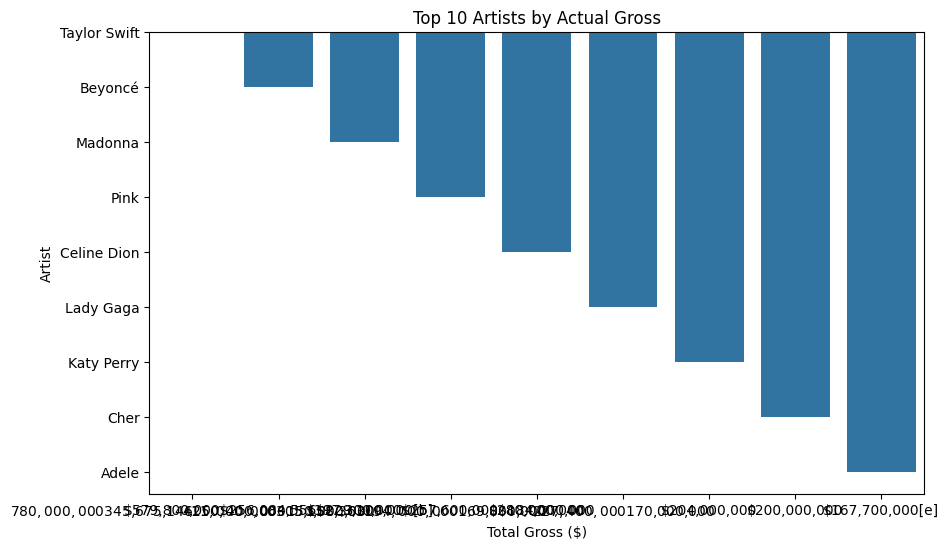

In [39]:
# Top Artists by Total Gross
top_artists = tours_data.groupby('Artist')['Actual\xa0gross'].sum().sort_values(ascending=False).head(10)
print(top_artists)

plt.figure(figsize=(10,6))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Top 10 Artists by Actual Gross")
plt.xlabel("Total Gross ($)")
plt.show()

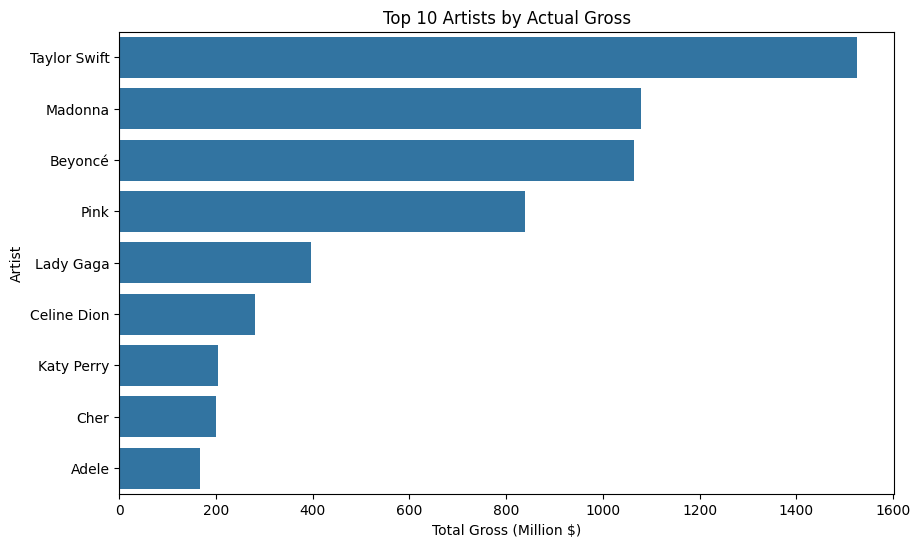

In [47]:
import matplotlib.ticker as mtick

# Scale values into millions
top_artists_mil = top_artists / 1_000_000

plt.figure(figsize=(10,6))
sns.barplot(x=top_artists_mil.values, y=top_artists_mil.index)
plt.title("Top 10 Artists by Actual Gross")
plt.xlabel("Total Gross (Million $)")
plt.show()


In [ ]:
# Drop 'Year(s)'
tours_data = tours_data.drop(columns=['Year(s)'])

In [62]:
# Drop 'Ref.'
tours_data = tours_data.drop(columns=['Ref.'])

In [63]:
print (tours_data)

    Rank  Actual gross Adjusted gross (in 2022 dollars)        Artist  \
0      1   780000000.0                     $780,000,000  Taylor Swift   
1      2   579800000.0                     $579,800,000       Beyoncé   
2      3   411000000.0                     $560,622,615       Madonna   
3      4   397300000.0                     $454,751,555          Pink   
4      5   345675146.0                     $402,844,849  Taylor Swift   
5      6   305158363.0                     $388,978,496       Madonna   
6      7   280000000.0                     $381,932,682   Celine Dion   
7      7   257600000.0                     $257,600,000          Pink   
8      9   256084556.0                     $312,258,401       Beyoncé   
9     10   250400000.0                     $309,141,878  Taylor Swift   
10    11   229100000.0                     $283,202,896       Beyoncé   
11    12   227400000.0                     $295,301,479     Lady Gaga   
12    13   204000000.0                     $251,856

In [64]:
tours_data.rename(columns={"Adjusted\xa0gross (in 2022 dollars)": "Adjusted Gross 2022"}, inplace=True)

In [65]:
# Check result
print(tours_data.isnull().sum())
tours_data.head()

Rank                   0
Actual gross           0
Adjusted Gross 2022    0
Artist                 0
Tour title             0
Shows                  0
Average gross          0
Start Year             0
End Year               0
dtype: int64


,Rank,Actual gross,Adjusted Gross 2022,Artist,Tour title,Shows,Average gross,Start Year,End Year
0,1,780000000.0,"$780,000,000",Taylor Swift,The Eras Tour †,56,"$13,928,571",2023,2024
1,2,579800000.0,"$579,800,000",Beyoncé,Renaissance World Tour,56,"$10,353,571",2023,2023
2,3,411000000.0,"$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],85,"$4,835,294",2008,2009
3,4,397300000.0,"$454,751,555",Pink,Beautiful Trauma World Tour,156,"$2,546,795",2018,2019
4,5,345675146.0,"$402,844,849",Taylor Swift,Reputation Stadium Tour,53,"$6,522,173",2018,2018


# Technical Report – Data Cleaning & EDA

### Dataset Description and Source  
The dataset contains information on the **highest-grossing concert tours** by various artists. Columns include rank, artist, tour title, year(s), gross revenue (actual and adjusted), average gross, number of shows, and references. The source appears to be a Wikipedia table of top concert tours, collected into CSV form.  

### Data Quality Issues Found  
- **Missing values:** Present in the `Peak` and `All Time Peak` columns.  
- **Incorrect data types:** Monetary values (`Actual gross`, `Adjusted gross`, `Average gross`) were stored as strings with `$`, commas, and footnote markers like `[e]`.  
- **Inconsistent/invalid values:** Brackets and symbols in columns such as `Peak` (e.g., `2[4]`) and footnote codes in gross columns.  
- **Duplicates:** No fully duplicated rows, but overlapping categories were noted.  

### Cleaning Methodology and Decisions Made  
- Dropped `All Time Peak` due to excessive missing values.  
- Filled missing values in `Peak` with `"N/A"`.  
- Cleaned monetary columns by removing `$`, commas, and footnotes, then converted them to numeric (`float`).  
- Extracted clean years from `Year(s)` where ranges existed.  
- Removed extraneous reference column (`Ref.`).  
- Standardized column names for easier analysis.  

### Key EDA Findings and Insights  
- **Top Grossing Artists:** Taylor Swift leads with *The Eras Tour*, surpassing $1.5 billion in actual gross. Madonna, Beyoncé, Pink, and Lady Gaga also appear among the top performers.  
- **Trend by Year:** The number of high-grossing tours increases in recent decades, showing the expansion of global touring markets.  
- **Revenue Distribution:** Strong positive correlation between `Actual gross`, `Adjusted gross`, and `Average gross`. Outliers correspond to mega-tours by globally dominant artists.  

### Recommendations for Further Analysis  
- Compare **adjusted vs actual gross** to evaluate inflation effects on tour revenues.  
- Explore **average gross per show** to compare efficiency between artists with fewer vs more shows.  
- Add external data (e.g., ticket prices, attendance, regions) for deeper insights into profitability.  
- Perform **time-series analysis** to forecast future high-grossing tours based on past growth.  
